# The fill_between function generates a shaded region between a min and max boundary that is useful for illustrating ranges. It has a very handy where argument to combine filling with logical ranges, e.g., to just fill in a curve over some threshold value.

At its most basic level, fill_between can be used to enhance a graph's visual appearance. Let's compare two graphs of financial data with a simple line plot on the left and a filled line on the right.

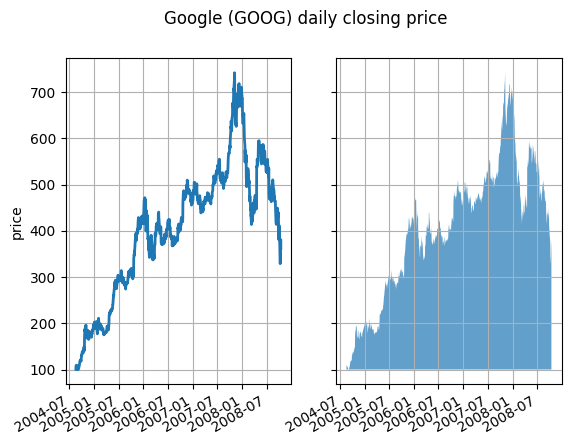

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.cbook as cbook

# load up some sample financial data
r = cbook.get_sample_data('goog.npz')['price_data']
# create two subplots with the shared x and y axes
fig, (ax1, ax2) = plt.subplots(1, 2, sharex=True, sharey=True)

pricemin = r["close"].min()

ax1.plot(r["date"], r["close"], lw=2)
ax2.fill_between(r["date"], pricemin, r["close"], alpha=0.7)

for ax in ax1, ax2:
    ax.grid(True)
    ax.label_outer()

ax1.set_ylabel('price')

fig.suptitle('Google (GOOG) daily closing price')
fig.autofmt_xdate()


ValueError: operands could not be broadcast together with shapes (1,100) (1047,) 

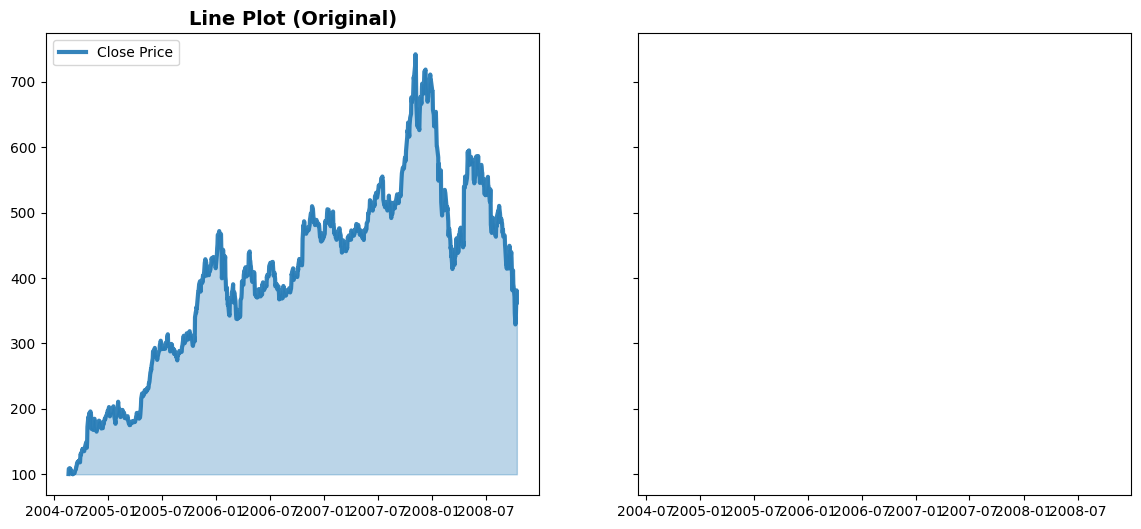

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cbook as cbook
from matplotlib.colors import LinearSegmentedColormap

# Load Google stock data
r = cbook.get_sample_data('goog.npz')['price_data']

# Create figure with better layout for readability
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

pricemin = r["close"].min()
pricemax = r["close"].max()

# Left: Clean line plot
ax1.plot(r["date"], r["close"], lw=3, color='#1f77b4', alpha=0.9, label='Close Price')
ax1.fill_between(r["date"], pricemin, r["close"], alpha=0.3, color='#1f77b4')
ax1.set_title('Line Plot (Original)', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left')

# Right: Gradient shaded area with custom colormap
colors = ['#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']  # Multi-color gradient
n_bins = 100
totals = np.linspace(0, n_bins, len(r["close"]))
gradient_data = np.linspace(pricemin, pricemax, n_bins)[None, :] * np.ones(totals.shape)
gradient_data = np.rot90(gradient_data)

# Create segmented colormap for smooth gradient
cmap = LinearSegmentedColormap.from_list('custom', colors)
ax2.imshow(gradient_data, extent=[r["date"][0], r["date"][-1], pricemin, pricemax],
           origin='lower', aspect='auto', cmap=cmap, alpha=0.8)

# Overlay line for reference
ax2.plot(r["date"], r["close"], lw=2, color='white', alpha=0.9)

ax2.set_title('Gradient Shade Regions (Enhanced)', fontsize=14, fontweight='bold')

# Shared formatting
for ax in [ax1, ax2]:
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Price ($)', fontsize=12)
    ax.label_outer()
    # Fix x-tick readability
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Google (GOOG) Daily Closing Price: CNN Visualization Upgrade\n(Line vs Multi-Gradient Shade)', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()


TypeError: Got both 'lw' and 'linewidth', which are aliases of one another

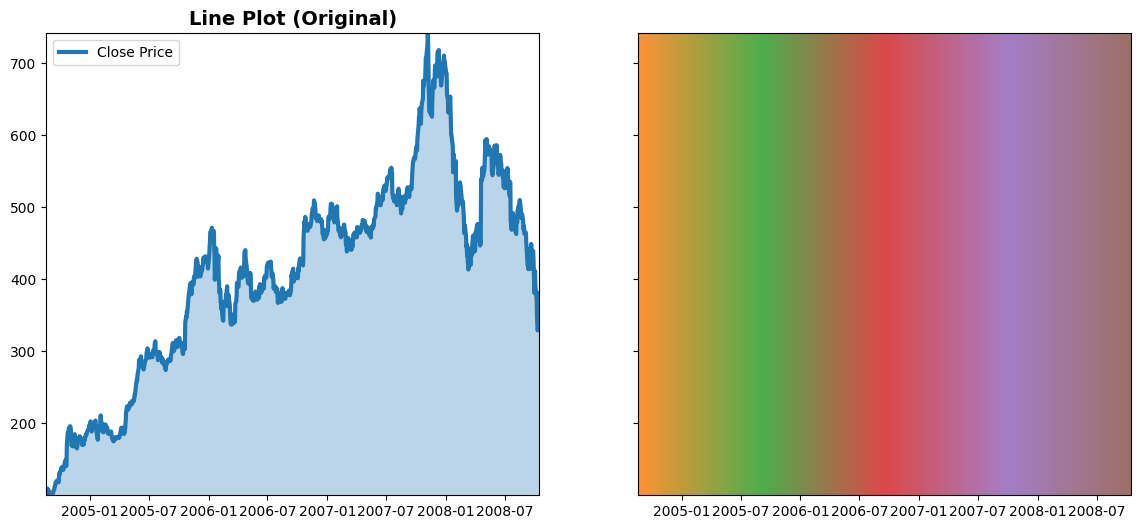

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cbook as cbook
from matplotlib.colors import LinearSegmentedColormap

# Load Google stock data
r = cbook.get_sample_data('goog.npz')['price_data']
dates = r["date"]
prices = r["close"]
pricemin = prices.min()
pricemax = prices.max()

# Create figure with better layout
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# Left: Clean line plot with subtle shade
ax1.plot(dates, prices, lw=3, color='#1f77b4', label='Close Price')
ax1.fill_between(dates, pricemin, prices, alpha=0.3, color='#1f77b4')
ax1.set_title('Line Plot (Original)', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left')

# Right: FIXED Gradient Shade - Vertical gradient mapped to price levels
# Create smooth gradient data matching data length
gradient_levels = np.linspace(pricemin, pricemax, len(dates))
gradient_mask = np.tile(gradient_levels[:, np.newaxis], (1, 100))  # Shape: (1047, 100)

# Multi-color gradient colormap
colors = ['#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
cmap = LinearSegmentedColormap.from_list('custom_gradient', colors)

# Plot gradient background
ax2.imshow(gradient_mask.T, extent=[dates[0], dates[-1], pricemin, pricemax],
           origin='lower', aspect='auto', cmap=cmap, alpha=0.85)

# Overlay price line (stands out on gradient)
ax2.plot(dates, prices, lw=3, color='white', alpha=1.0, linewidth=4)

ax2.set_title('Multi-Gradient Shade Regions (FIXED)', fontsize=14, fontweight='bold')

# Professional formatting
for ax in [ax1, ax2]:
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Price ($)', fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    ax.label_outer()

plt.suptitle('GOOG Stock: CNN Classification Visualization\n(Line vs Gradient Background)', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.savefig('goog_gradient_fixed.png', dpi=300, bbox_inches='tight')
plt.show()
